# Clasificador con árbol de decisión

In [1]:
import pandas as pd

df = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None,
    names=['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation',
           'relationship','race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'],
    na_values=' ?'
    )

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [3]:
df = df.drop_duplicates(df)

In [4]:
df.income.value_counts()

income
<=50K    24698
>50K      7839
Name: count, dtype: int64

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split

X = df.drop('income', axis = 1)
X = X.select_dtypes(include=[np.number])
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
    )

print(X_train.shape)
print(X_test.shape)

(26029, 6)
(6508, 6)


In [27]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    #max_depth=2,
    random_state=1,
    )

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [7]:
from sklearn.metrics import classification_report
print(classification_report(y_train, model.predict(X_train)))

              precision    recall  f1-score   support

       <=50K       1.00      1.00      1.00     19758
        >50K       1.00      1.00      1.00      6271

    accuracy                           1.00     26029
   macro avg       1.00      1.00      1.00     26029
weighted avg       1.00      1.00      1.00     26029



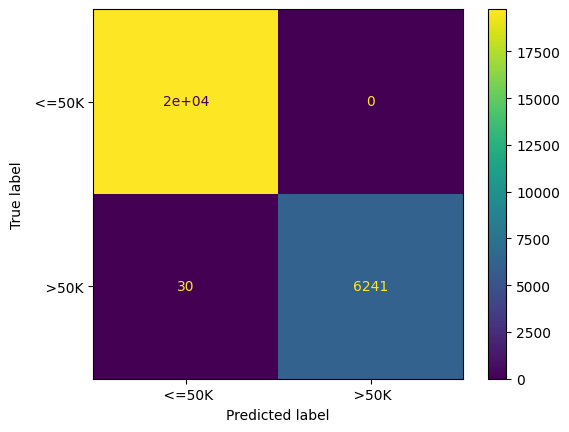

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_train, y_train);

In [9]:
from sklearn.metrics import classification_report
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

       <=50K       0.85      0.85      0.85      4940
        >50K       0.53      0.52      0.52      1568

    accuracy                           0.77      6508
   macro avg       0.69      0.69      0.69      6508
weighted avg       0.77      0.77      0.77      6508



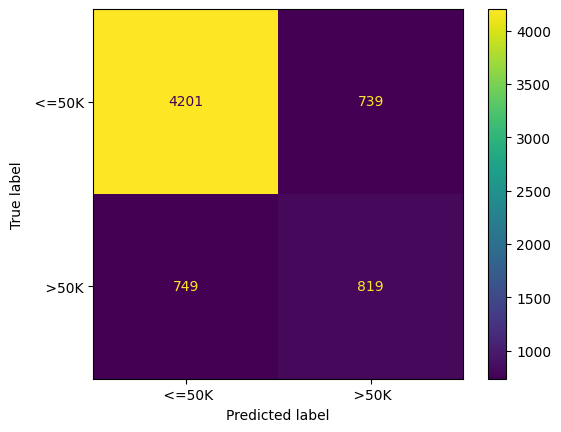

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test);

¡Los árboles de decisión tienden a sobreajustarse, deben regularizarse sí o sí!

Los árboles no tienen pesos asociados a los atributos. En lugar de ello, podemos obtener la **importancia relativa** de cada atributo, que se obtiene a partir de la ganancia de información de cada uno de ellos.

In [11]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False)

fnlwgt            0.393973
age               0.195487
capital-gain      0.163753
education-num     0.113693
hours-per-week    0.077684
capital-loss      0.055410
dtype: float64

Como no hay coeficientes, no hay ecuación. En su lugar se puede obtener el grafo del árbol de decisión. De esta manera, los árboles, al igual que los modelos lineales, son modelos de **caja blanca**, o explicables. Un modelo de caja blanca (o *white-box model*) en aprendizaje de máquina es un tipo de modelo cuyo funcionamiento interno es transparente y comprensible para las personas. Por eso también se le llama modelo explicable o interpretable.  En un árbol las decisiones se representan como reglas tipo “si-entonces”.

In [12]:
from sklearn.tree import export_text
r = export_text(model, feature_names=list(X.columns.values))
print(r)

|--- capital-gain <= 5119.00
|   |--- education-num <= 12.50
|   |   |--- age <= 33.50
|   |   |   |--- age <= 26.50
|   |   |   |   |--- age <= 23.50
|   |   |   |   |   |--- capital-loss <= 2713.50
|   |   |   |   |   |   |--- hours-per-week <= 45.50
|   |   |   |   |   |   |   |--- fnlwgt <= 545665.50
|   |   |   |   |   |   |   |   |--- education-num <= 3.50
|   |   |   |   |   |   |   |   |   |--- fnlwgt <= 172773.00
|   |   |   |   |   |   |   |   |   |   |--- fnlwgt <= 149178.50
|   |   |   |   |   |   |   |   |   |   |   |--- class:  <=50K
|   |   |   |   |   |   |   |   |   |   |--- fnlwgt >  149178.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |--- fnlwgt >  172773.00
|   |   |   |   |   |   |   |   |   |   |--- class:  <=50K
|   |   |   |   |   |   |   |   |--- education-num >  3.50
|   |   |   |   |   |   |   |   |   |--- age <= 21.50
|   |   |   |   |   |   |   |   |   |   |--- class:  <=50K
|   |   |   

Con el método **plot_tree** se obtiene el gráfico del árbol. Aquí, debido a que es un árbol muy complejo, solo se muestran los 3 primeros niveles.

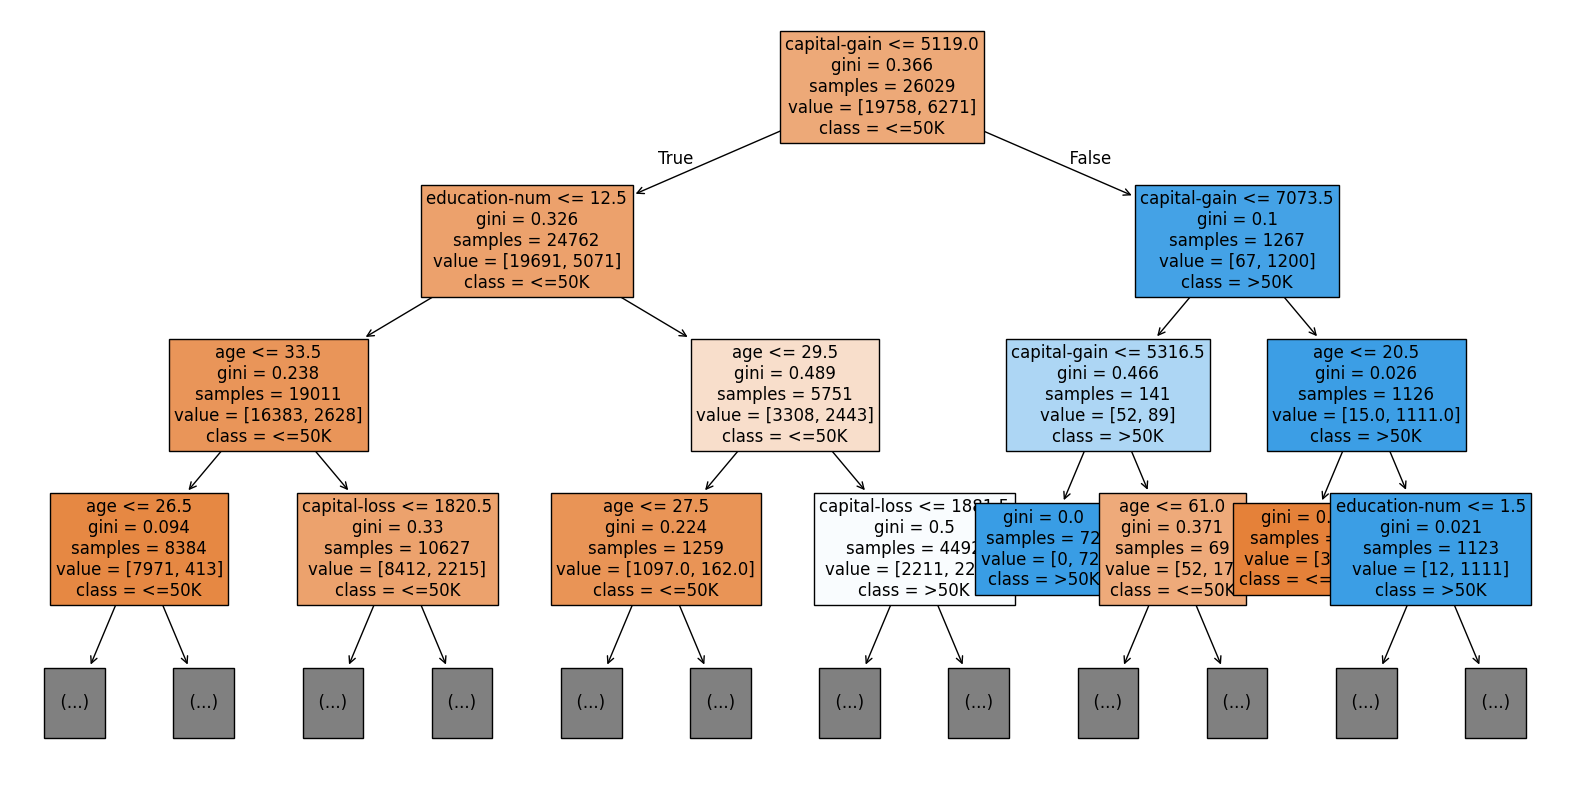

In [13]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    max_depth=3,
    filled=True,
    feature_names=X.columns,
    class_names=['<=50K', '>50K'],
    fontsize=12
    )
plt.show();

# Prunning (podado)

Ya se vio que los árboles de decisión se sobreajustan, así que es imprescindible intentar redcir la complejidad de estos para que generalicen mejor.

En el contexto de los árboles a este proceso de reducción de complejidad se le conoce como podado o **prunning**.

Hay varios métodos que se pueden usar para hacer esto. Vamos a ver los 2 más comunes.

## Factor de complejidad ccp_alpha

El factor de comlejidad **ccp_alpha** es un hiperparámetro que hace podado basado en costos: Un valor **ccp_alpha** determina un umbral de costo a partir del cual se podan las ramas del árbol.

El algoritmo comienza podando los nodos que menos contribuyen a la reducción del error de clasificación, es decir, los "enlaces más débiles".

Al aumentar el valor de ccp_alpha, se podan más nodos, resultando en un árbol más simple.

Valores más altos de ccp_alpha conducen a árboles más pequeños y simples.

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_le = le.fit_transform(y_train)
y_test_le = le.fit_transform(y_test)

grid = {'ccp_alpha':np.logspace(-3, 3)}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=1),
    param_grid=grid,
    scoring='recall')

grid_search.fit(X_train, y_train_le)


print(f'Best score: {grid_search.best_score_:.2f} with {grid_search.best_params_}')
print(f'Train score: {grid_search.score(X_train, y_train_le):.2f}')
print(f'Test score: {grid_search.score(X_test, y_test_le):.2f}')

,estimator,DecisionTreeC...andom_state=1)
,param_grid,{'ccp_alpha': array([1.0000...00000000e+03])}
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [15]:
print(classification_report(
    y_test_le,
    grid_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

       <=50K       0.86      0.89      0.87      4940
        >50K       0.61      0.55      0.58      1568

    accuracy                           0.81      6508
   macro avg       0.73      0.72      0.73      6508
weighted avg       0.80      0.81      0.80      6508



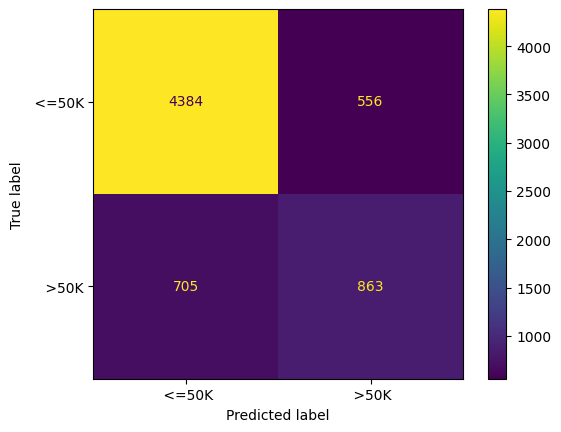

In [16]:
ConfusionMatrixDisplay.from_estimator(
    grid_search.best_estimator_,
    X_test,
    y_test_le,
    display_labels=le.classes_
    );

In [17]:
r = export_text(grid_search.best_estimator_, feature_names=list(X.columns.values))
print(r)

|--- capital-gain <= 5119.00
|   |--- education-num <= 12.50
|   |   |--- age <= 33.50
|   |   |   |--- class: 0
|   |   |--- age >  33.50
|   |   |   |--- class: 0
|   |--- education-num >  12.50
|   |   |--- age <= 29.50
|   |   |   |--- class: 0
|   |   |--- age >  29.50
|   |   |   |--- class: 1
|--- capital-gain >  5119.00
|   |--- class: 1



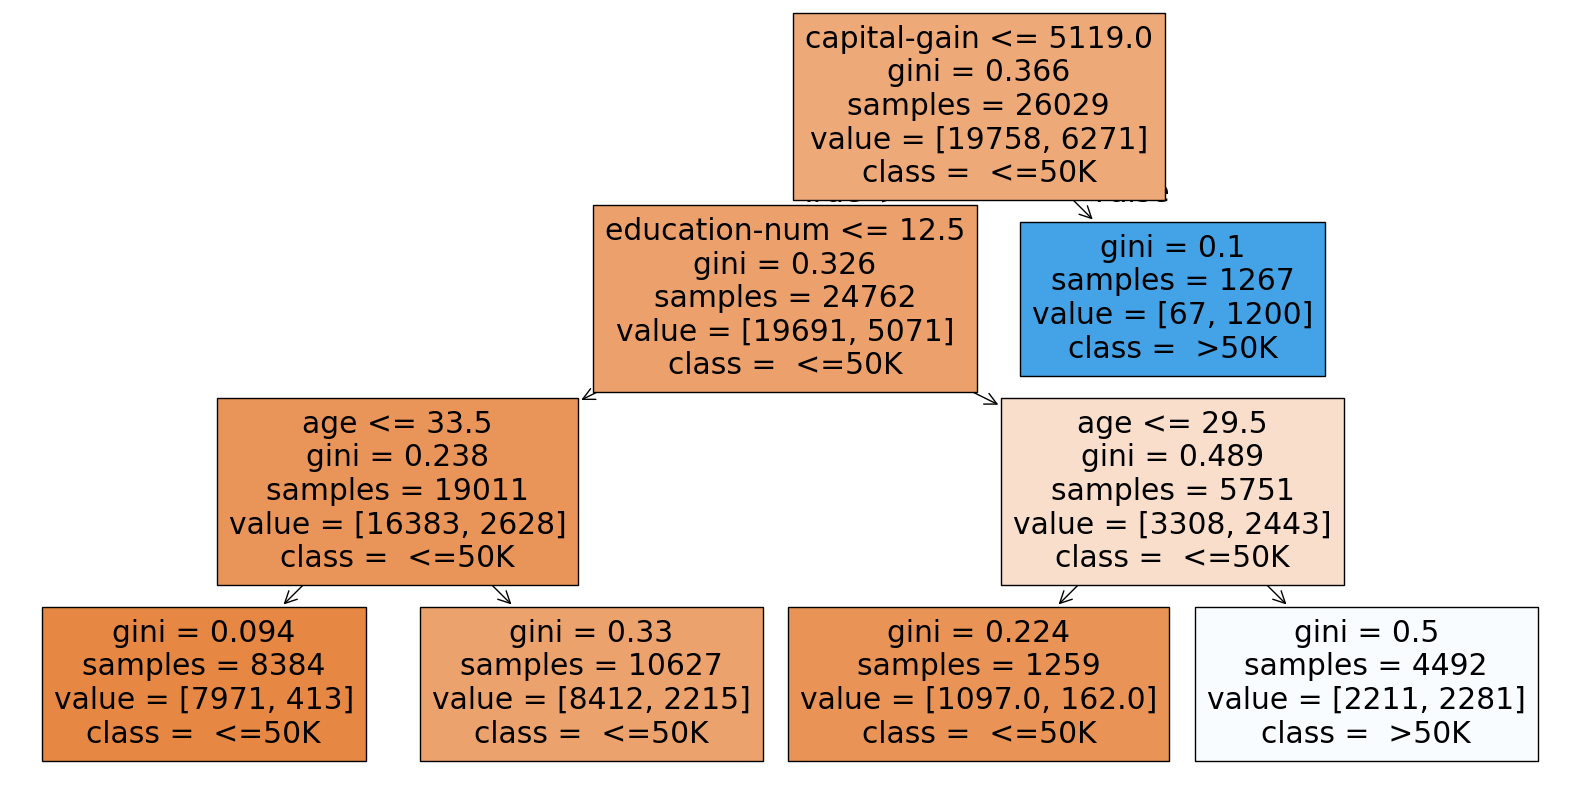

In [18]:
plt.figure(figsize=(20, 10))
plot_tree(
    grid_search.best_estimator_,
    filled=True,
    feature_names=X.columns,
    class_names=le.classes_
    )
plt.show();

In [19]:
importances = pd.Series(grid_search.best_estimator_.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False)

capital-gain      0.516144
education-num     0.281751
age               0.202105
fnlwgt            0.000000
capital-loss      0.000000
hours-per-week    0.000000
dtype: float64

## Métodos pre-poda

En estos mátodos se establece un criterio para detener el crecimiento del árbol antes de que se vuelva demasiado complejo. Por ejemplo, se puede limitar la profundidad máxima del árbol ( `max_depth`), el número mínimo de muestras para dividir un nodo (`min_samples_split`), o el número mínimo de muestras por hoja (`min_samples_leaf`).

Ventajas: Es computacionalmente más eficiente que podar por factor de complejidad, ya que evita construir un árbol completo y luego podarlo.

Desventajas: Puede resultar en un árbol sub-óptimo si el criterio de detención es demasiado restrictivo.

In [20]:
grid = {
    'max_depth': [2,3,4,5],
    'min_samples_leaf':[3,5,7]
    }

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=1),
    param_grid=grid,
    scoring='recall')

grid_search.fit(X_train, y_train_le)

print(f'Best score: {grid_search.best_score_:.2f} with {grid_search.best_params_}')
print(f'Train score: {grid_search.score(X_train, y_train_le):.2f}')
print(f'Test score: {grid_search.score(X_test, y_test_le):.2f}')

Best score: 0.54 with {'max_depth': 3, 'min_samples_leaf': 3}
Train score: 0.55
Test score: 0.55


In [21]:
print(classification_report(
    y_test_le,
    grid_search.best_estimator_.predict(X_test),
    target_names=le.classes_
    ))

              precision    recall  f1-score   support

       <=50K       0.86      0.89      0.88      4940
        >50K       0.61      0.55      0.58      1568

    accuracy                           0.81      6508
   macro avg       0.74      0.72      0.73      6508
weighted avg       0.80      0.81      0.80      6508



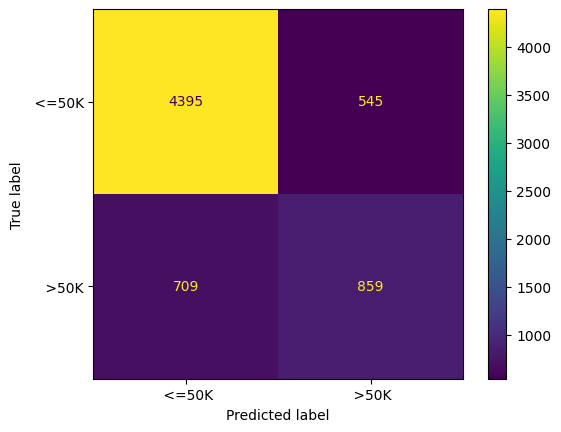

In [22]:
ConfusionMatrixDisplay.from_estimator(
    grid_search.best_estimator_,
    X_test,
    y_test_le,
    display_labels=le.classes_
    );

In [23]:
r = export_text(grid_search.best_estimator_, feature_names=list(X.columns.values))
print(r)

|--- capital-gain <= 5119.00
|   |--- education-num <= 12.50
|   |   |--- age <= 33.50
|   |   |   |--- class: 0
|   |   |--- age >  33.50
|   |   |   |--- class: 0
|   |--- education-num >  12.50
|   |   |--- age <= 29.50
|   |   |   |--- class: 0
|   |   |--- age >  29.50
|   |   |   |--- class: 1
|--- capital-gain >  5119.00
|   |--- capital-gain <= 7073.50
|   |   |--- capital-gain <= 5316.50
|   |   |   |--- class: 1
|   |   |--- capital-gain >  5316.50
|   |   |   |--- class: 0
|   |--- capital-gain >  7073.50
|   |   |--- age <= 20.50
|   |   |   |--- class: 0
|   |   |--- age >  20.50
|   |   |   |--- class: 1



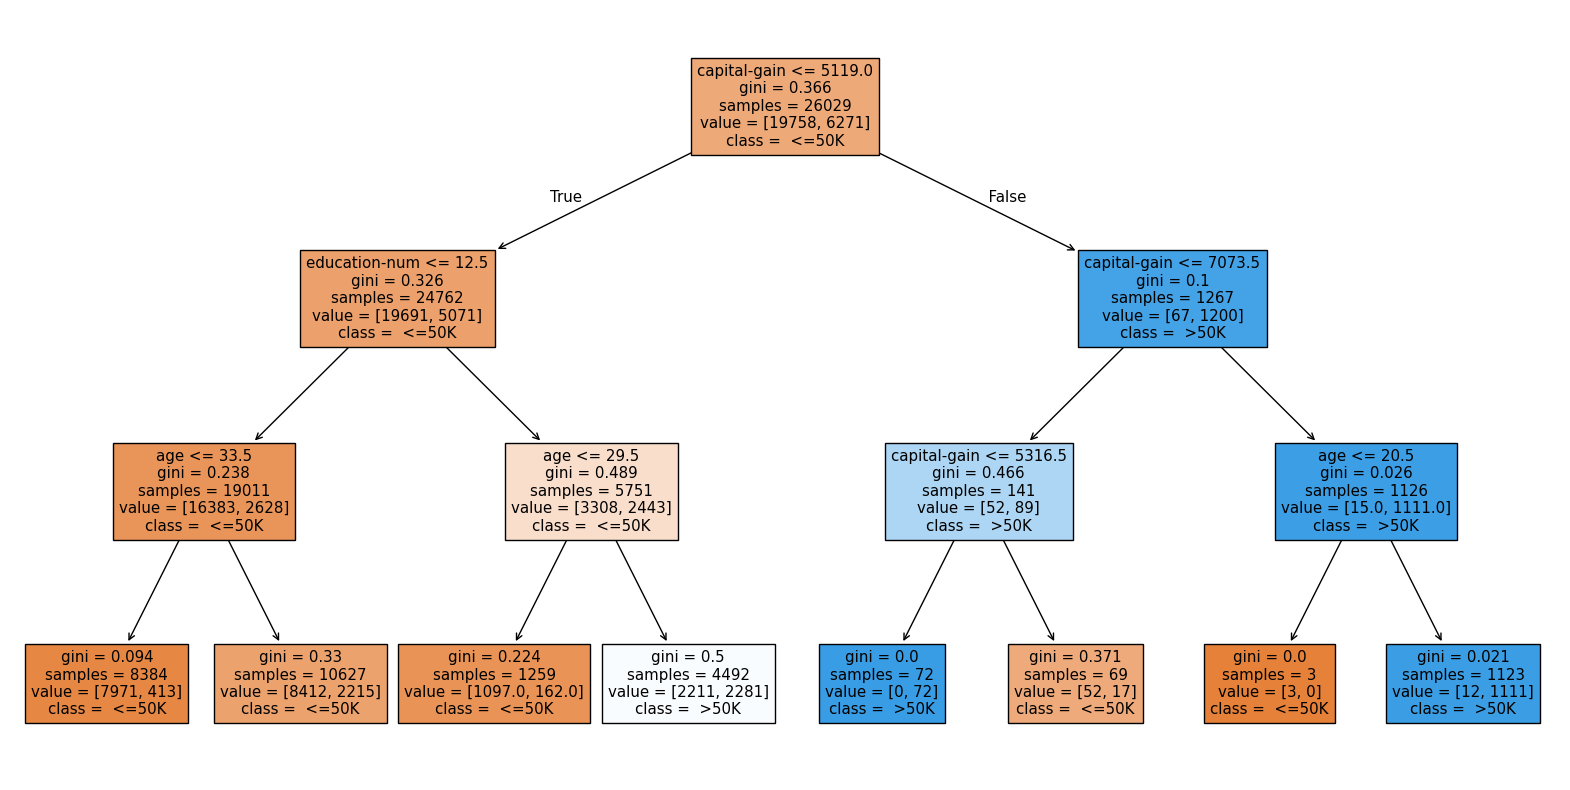

In [24]:
plt.figure(figsize=(20, 10))
plot_tree(
    grid_search.best_estimator_,
    filled=True,
    feature_names=X.columns,
    class_names=le.classes_,
    #max_depth=3
    )
plt.show();

In [25]:
importances = pd.Series(grid_search.best_estimator_.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False)

capital-gain      0.528087
education-num     0.273510
age               0.198402
fnlwgt            0.000000
capital-loss      0.000000
hours-per-week    0.000000
dtype: float64